In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [ ]:

df = pd.read_csv('/content/preprocessed_data.csv')

df.head()


,budget,genres,original_language,original_title,overview,popularity,production_companies,production_countries,runtime,spoken_languages,revenue,release_year,release_month,release_day,profit,profit_margin
0,500000,"Drama, Horror, Thriller, Romance",en,May,Psychological horror about a lonely young woma...,8.398158,"A Loopy Production LLC, 2 Loop Films",United States of America,93.0,English,1.502770e+05,2002.0,1.0,13.0,-3.497230e+05,-0.699446
1,2300000,"Comedy, Crime, Thriller",en,Curdled,"Gabriella, a Columbian immigrant, is obsessed ...",2.781581,Tinderbox Films,United States of America,88.0,"English, Español",2.209826e+06,1996.0,9.0,6.0,-9.017376e+04,-0.039206
2,0,"Thriller, Action, Drama, War",en,'71,A young British soldier must find his way back...,7.080550,"Screen Yorkshire, British Film Institute (BFI)...",United Kingdom,99.0,English,1.625847e+06,2014.0,10.0,10.0,1.625847e+06,0.000000
3,2000000,"Adventure, Action, Thriller, Science Fiction",en,Mad Max 2,Max Rockatansky returns as the heroic loner wh...,11.189831,Kennedy Miller Productions,Australia,95.0,English,2.460083e+07,1981.0,12.0,24.0,2.260083e+07,6.643274
4,52000000,Drama,en,Apollo 13,The true story of technical troubles that scut...,18.761467,"Imagine Entertainment, Universal Pictures",United States of America,140.0,English,1.809885e+08,1995.0,6.0,30.0,1.197271e+08,5.831499


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7398 entries, 0 to 7397
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                7398 non-null   int64  
 1   genres                7375 non-null   object 
 2   original_language     7398 non-null   object 
 3   original_title        7398 non-null   object 
 4   overview              7398 non-null   object 
 5   popularity            7398 non-null   float64
 6   production_companies  6984 non-null   object 
 7   production_countries  7241 non-null   object 
 8   runtime               7398 non-null   float64
 9   spoken_languages      7322 non-null   object 
 10  revenue               7398 non-null   float64
 11  release_year          7397 non-null   float64
 12  release_month         7397 non-null   float64
 13  release_day           7397 non-null   float64
 14  profit                7398 non-null   float64
 15  profit_margin        

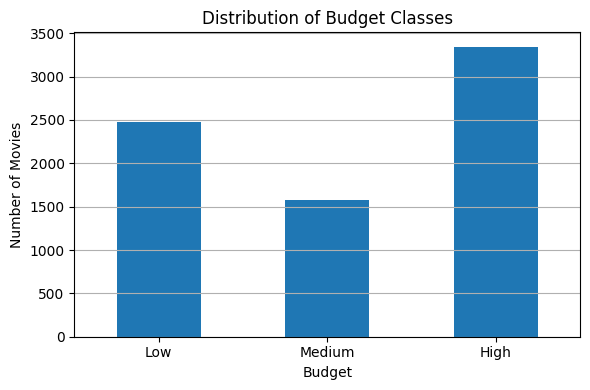

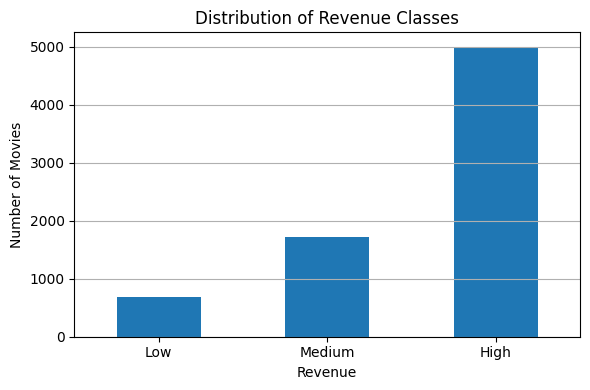

In [ ]:

# Binning the 'budget' column into 3 categories for classification
bins = [0, 1000000, 10000000, df['budget'].max()]
labels = ['Low', 'Medium', 'High']
bins = [0, 1000000, 10000000, df['revenue'].max()]
labels = ['Low', 'Medium', 'High']
df['budget_class'] = pd.cut(df['budget'], bins=bins, labels=labels, include_lowest=True)
df['revenue_class'] = pd.cut(df['revenue'], bins=bins, labels=labels, include_lowest=True)


# Plotting class distribution
class_counts = df['budget_class'].value_counts().sort_index()

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')
plt.title("Distribution of Budget Classes")
plt.xlabel("Budget")
plt.ylabel("Number of Movies")
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


class_counts = df['revenue_class'].value_counts().sort_index()

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')
plt.title("Distribution of Revenue Classes")
plt.xlabel("Revenue")
plt.ylabel("Number of Movies")
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import numpy as np

# Step 1: Drop unnecessary columns
df_nb = df.drop(columns=['overview', 'original_title', 'production_companies',
                         'production_countries', 'spoken_languages']).dropna()

# Step 2: Label encode categorical features
for col in ['genres', 'original_language']:
    df_nb[col] = LabelEncoder().fit_transform(df_nb[col])

# Step 3: Create revenue class label (Low, Medium, High)
bins = [0, 10000000, 50000000, df_nb['revenue'].max()]
labels = ['Low', 'Medium', 'High']
df_nb['revenue_class'] = pd.cut(df_nb['revenue'], bins=bins, labels=labels)

# Step 4: Encode the revenue class
df_nb['revenue_class_encoded'] = LabelEncoder().fit_transform(df_nb['revenue_class'])

# Step 5: Normalize numeric features for MultinomialNB
for col in ['profit', 'profit_margin']:
    min_val = df_nb[col].min()
    if min_val < 0:
        df_nb[col] = df_nb[col] - min_val

df_nb[['profit', 'profit_margin']] = MinMaxScaler().fit_transform(df_nb[['profit', 'profit_margin']])

# Step 6: Feature matrix and target
X = df_nb.drop(columns=['revenue', 'revenue_class', 'revenue_class_encoded', 'budget'])
y = df_nb['revenue_class_encoded']

# Step 7: Train-test split (disjoint sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()


((5899, 9),
 (1475, 9),
 revenue_class_encoded
 0    2040
 2    1982
 1    1877
 Name: count, dtype: int64,
 revenue_class_encoded
 1    504
 0    490
 2    481
 Name: count, dtype: int64)

In [ ]:
df_nb

,budget,genres,original_language,popularity,runtime,revenue,release_year,release_month,release_day,profit,profit_margin,revenue_class,revenue_class_encoded
0,500000,904,10,8.398158,93.0,1.502770e+05,2002.0,1.0,13.0,0.361440,0.039323,Low,1
1,2300000,570,10,2.781581,88.0,2.209826e+06,1996.0,9.0,6.0,0.362820,0.125704,Low,1
2,0,1407,10,7.080550,99.0,1.625847e+06,2014.0,10.0,10.0,0.371946,0.130834,Low,1
3,2000000,325,10,11.189831,95.0,2.460083e+07,1981.0,12.0,24.0,0.483489,1.000000,Medium,2
4,52000000,777,10,18.761467,140.0,1.809885e+08,1995.0,6.0,30.0,1.000000,0.893792,High,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7393,42000000,91,10,10.536644,108.0,9.608210e+07,1991.0,6.0,21.0,0.650904,0.299305,High,0
7394,0,856,10,2.624771,95.0,2.224714e+06,1995.0,5.0,26.0,0.375130,0.130834,Low,1
7395,12000000,1469,10,8.321647,114.0,3.600727e+07,1983.0,6.0,3.0,0.490969,0.392581,Medium,2
7396,24000000,541,10,4.197544,89.0,1.478268e+07,2001.0,11.0,21.0,0.314283,0.080586,Medium,2


In [ ]:
X_train

,genres,original_language,popularity,runtime,release_year,release_month,release_day,profit,profit_margin
7329,777,10,13.784411,118.0,2014.0,4.0,11.0,0.592423,1.000000
3159,541,10,7.181664,85.0,1982.0,12.0,10.0,0.462592,0.130834
3827,1436,10,6.426438,114.0,2002.0,11.0,6.0,0.666755,0.344141
5739,650,10,5.285420,86.0,2016.0,6.0,3.0,0.394371,0.130834
4528,821,10,12.807728,101.0,2012.0,6.0,1.0,0.425199,0.130834
...,...,...,...,...,...,...,...,...,...
5209,575,10,0.654549,89.0,1988.0,5.0,6.0,0.365060,0.130834
5244,608,10,5.759483,117.0,2002.0,8.0,23.0,0.531811,0.130834
5408,541,10,11.276024,108.0,2007.0,5.0,25.0,0.470612,1.000000
862,1128,20,1.405580,101.0,2002.0,9.0,6.0,0.376877,0.130834


In [ ]:
X_test

,genres,original_language,popularity,runtime,release_year,release_month,release_day,profit,profit_margin
3520,777,10,3.466204,104.0,1998.0,8.0,13.0,0.365313,0.130834
1933,9,10,11.600224,91.0,1993.0,9.0,17.0,0.364630,0.143427
3601,732,10,2.488750,131.0,2001.0,2.0,8.0,1.000000,0.528888
5787,925,10,11.107914,112.0,2010.0,12.0,27.0,0.451725,0.752396
2586,263,10,10.388183,110.0,1994.0,10.0,7.0,0.691889,0.310481
...,...,...,...,...,...,...,...,...,...
6284,756,10,2.203671,73.0,2015.0,4.0,18.0,0.363537,0.130834
5330,777,10,10.973822,138.0,2012.0,11.0,2.0,0.739472,0.429374
2292,1201,10,10.307277,90.0,2006.0,8.0,11.0,0.320265,0.102972
6684,575,10,8.795941,115.0,1992.0,3.0,26.0,0.638580,0.130834


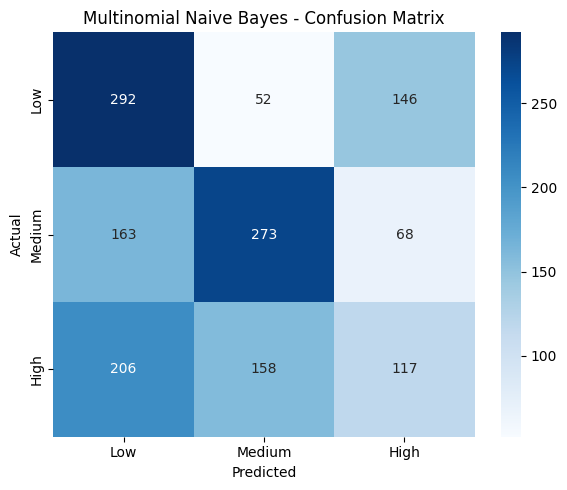

(0.4623728813559322,
 {'Low': {'precision': 0.44175491679273826,
   'recall': 0.5959183673469388,
   'f1-score': 0.5073848827106864,
   'support': 490.0},
  'Medium': {'precision': 0.5652173913043478,
   'recall': 0.5416666666666666,
   'f1-score': 0.5531914893617021,
   'support': 504.0},
  'High': {'precision': 0.35347432024169184,
   'recall': 0.24324324324324326,
   'f1-score': 0.2881773399014778,
   'support': 481.0},
  'accuracy': 0.4623728813559322,
  'macro avg': {'precision': 0.45348220944625933,
   'recall': 0.4602760924189495,
   'f1-score': 0.4495845706579555,
   'support': 1475.0},
  'weighted avg': {'precision': 0.4551529643946351,
   'recall': 0.4623728813559322,
   'f1-score': 0.4515528160400983,
   'support': 1475.0}})

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train Multinomial Naive Bayes
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)

# Evaluate
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)
mnb_report = classification_report(y_test, y_pred_mnb, target_names=['Low', 'Medium', 'High'], output_dict=True)
mnb_conf_matrix = confusion_matrix(y_test, y_pred_mnb)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(mnb_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multinomial Naive Bayes - Confusion Matrix")
plt.tight_layout()
plt.show()

mnb_accuracy, mnb_report


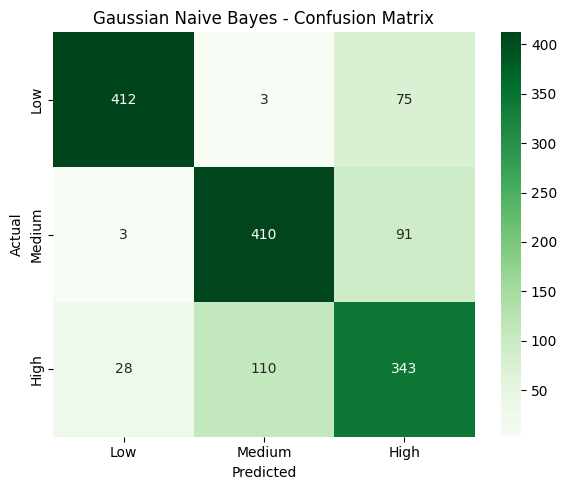

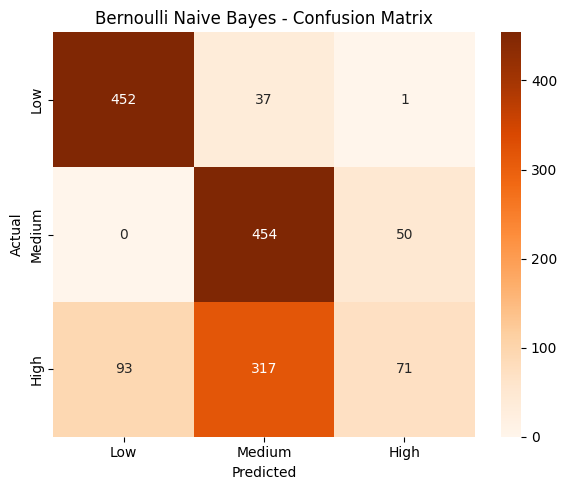

{'GaussianNB': {'accuracy': 0.7898305084745763,
  'report': {'Low': {'precision': 0.9300225733634312,
    'recall': 0.8408163265306122,
    'f1-score': 0.8831725616291533,
    'support': 490.0},
   'Medium': {'precision': 0.7839388145315488,
    'recall': 0.8134920634920635,
    'f1-score': 0.7984420642648491,
    'support': 504.0},
   'High': {'precision': 0.6738703339882122,
    'recall': 0.7130977130977131,
    'f1-score': 0.692929292929293,
    'support': 481.0},
   'accuracy': 0.7898305084745763,
   'macro avg': {'precision': 0.7959439072943973,
    'recall': 0.7891353677067964,
    'f1-score': 0.7915146396077651,
    'support': 1475.0},
   'weighted avg': {'precision': 0.7965748163527537,
    'recall': 0.7898305084745763,
    'f1-score': 0.7921819291435654,
    'support': 1475.0}}},
 'BernoulliNB': {'accuracy': 0.6623728813559322,
  'report': {'Low': {'precision': 0.8293577981651377,
    'recall': 0.9224489795918367,
    'f1-score': 0.8734299516908213,
    'support': 490.0},
   '

In [ ]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB

# ===================== Gaussian Naive Bayes =====================
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

gnb_accuracy = accuracy_score(y_test, y_pred_gnb)
gnb_report = classification_report(y_test, y_pred_gnb, target_names=['Low', 'Medium', 'High'], output_dict=True)
gnb_conf_matrix = confusion_matrix(y_test, y_pred_gnb)

# Plot Confusion Matrix for GaussianNB
plt.figure(figsize=(6, 5))
sns.heatmap(gnb_conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.tight_layout()
plt.show()

# ===================== Bernoulli Naive Bayes =====================
# Convert all features to binary for BernoulliNB
X_train_bin = (X_train > 0.5).astype(int)
X_test_bin = (X_test > 0.5).astype(int)

bnb = BernoulliNB()
bnb.fit(X_train_bin, y_train)
y_pred_bnb = bnb.predict(X_test_bin)

bnb_accuracy = accuracy_score(y_test, y_pred_bnb)
bnb_report = classification_report(y_test, y_pred_bnb, target_names=['Low', 'Medium', 'High'], output_dict=True)
bnb_conf_matrix = confusion_matrix(y_test, y_pred_bnb)

# Plot Confusion Matrix for BernoulliNB
plt.figure(figsize=(6, 5))
sns.heatmap(bnb_conf_matrix, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bernoulli Naive Bayes - Confusion Matrix")
plt.tight_layout()
plt.show()

# Return all metrics
{
    "GaussianNB": {"accuracy": gnb_accuracy, "report": gnb_report},
    "BernoulliNB": {"accuracy": bnb_accuracy, "report": bnb_report}
}


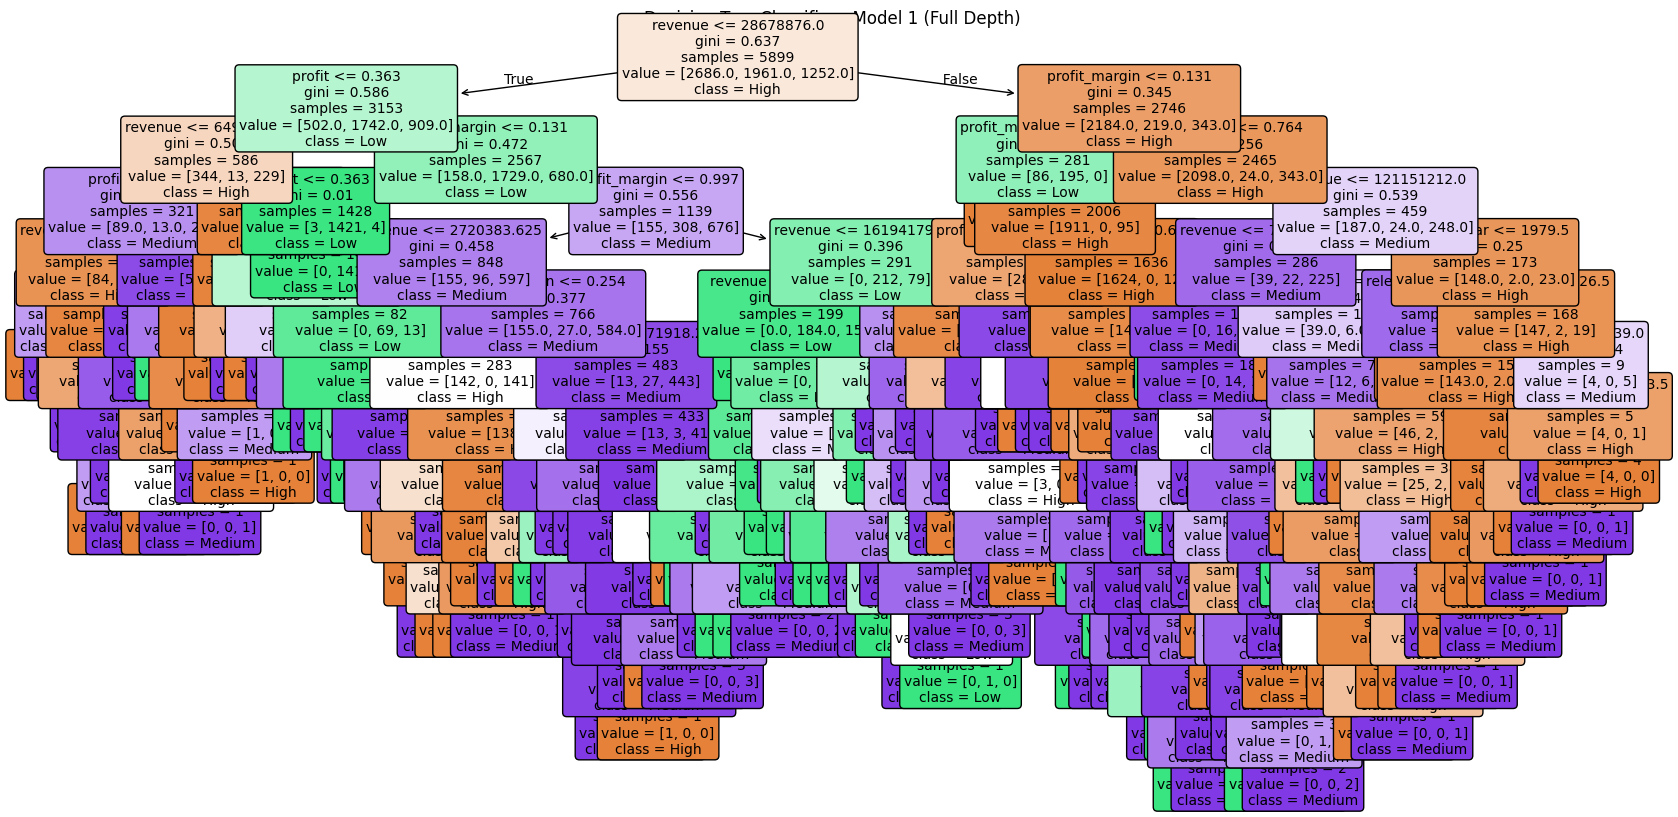

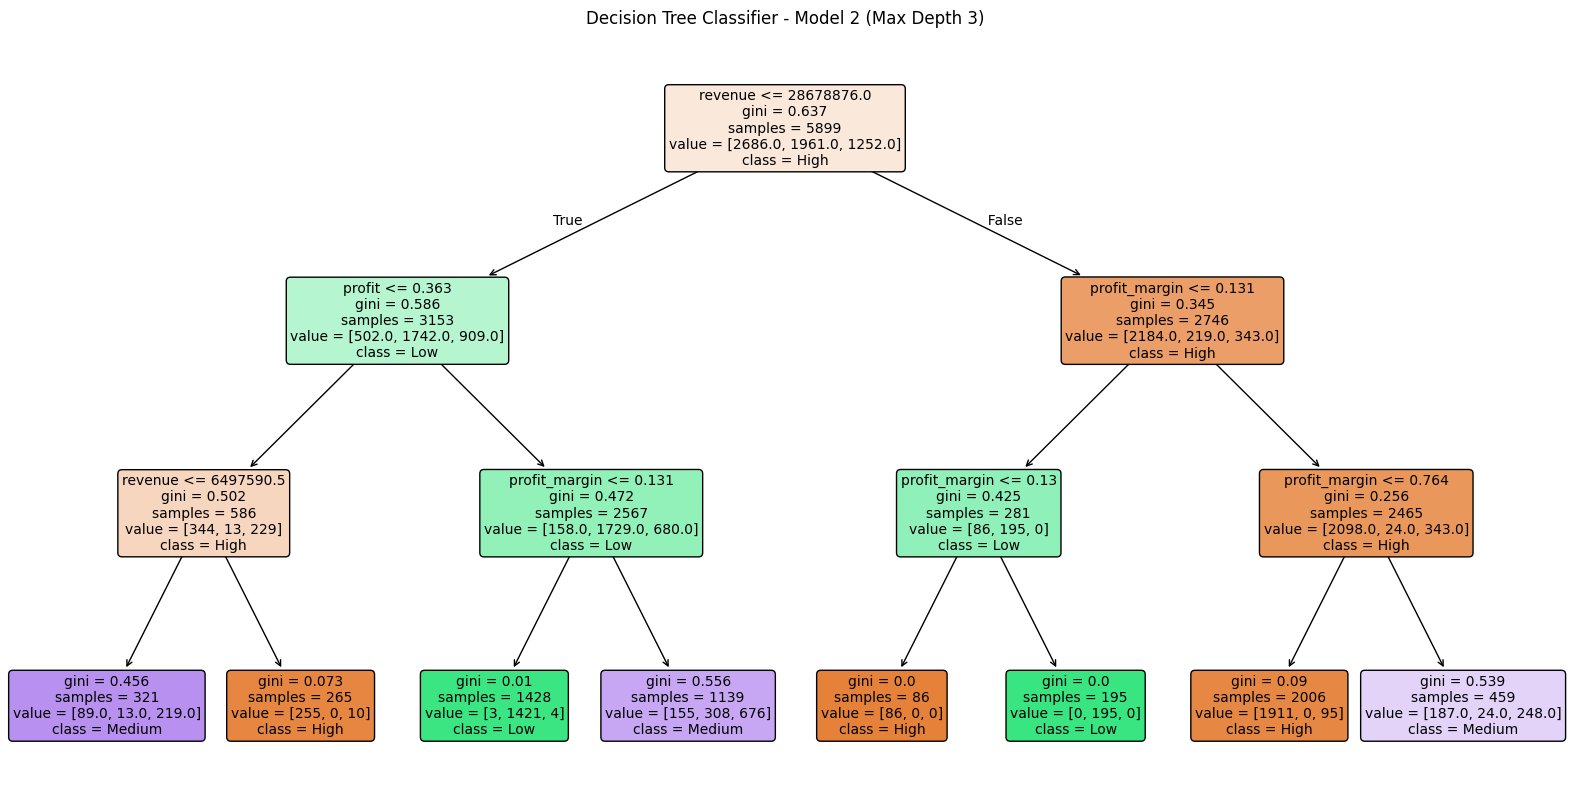

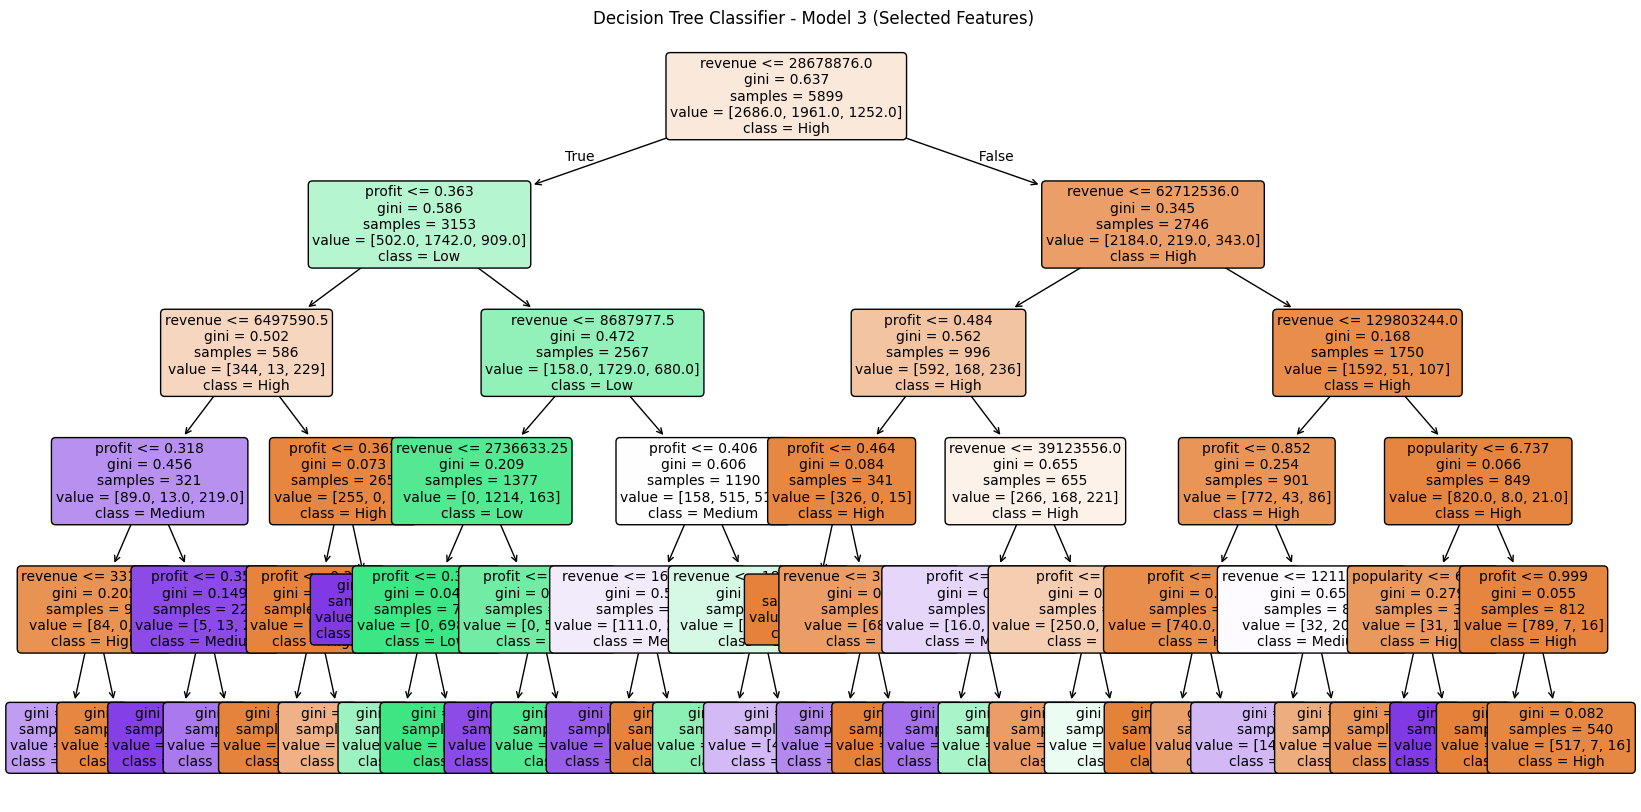


Model 1: Default Tree
Accuracy: 95.66%

Class        Precision  Recall     F1-Score   Support   
------------------------------------------------------------
High         0.97       0.98       0.97       656       
Low          0.96       0.97       0.97       502       
Medium       0.91       0.89       0.90       317       

Confusion Matrix:


<Figure size 600x500 with 0 Axes>

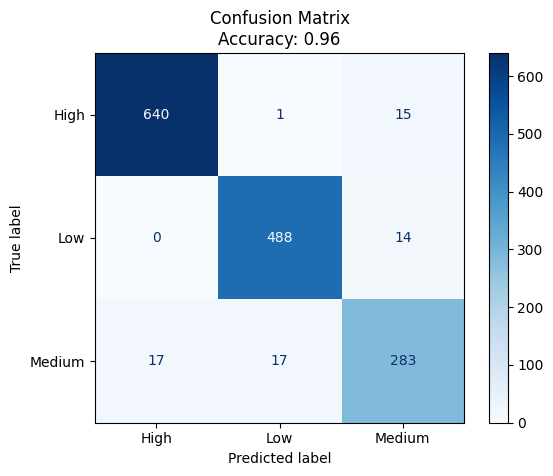


Model 2: Max Depth 3
Accuracy: 83.59%

Class        Precision  Recall     F1-Score   Support   
------------------------------------------------------------
High         0.95       0.81       0.88       656       
Low          0.99       0.83       0.90       502       
Medium       0.58       0.90       0.70       317       

Confusion Matrix:


<Figure size 600x500 with 0 Axes>

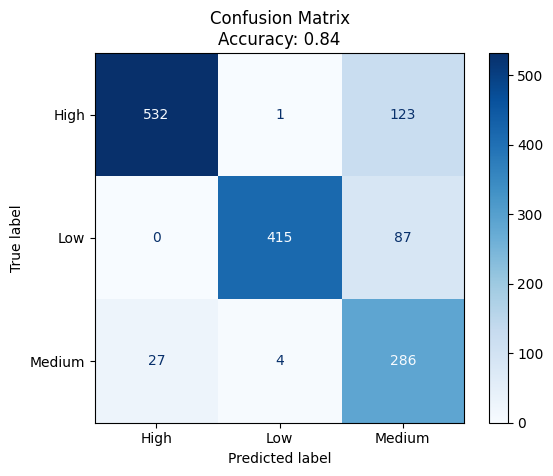


Model 3: Selected Features
Accuracy: 82.85%

Class        Precision  Recall     F1-Score   Support   
------------------------------------------------------------
High         0.92       0.93       0.93       656       
Low          0.80       0.86       0.83       502       
Medium       0.66       0.56       0.60       317       

Confusion Matrix:


<Figure size 600x500 with 0 Axes>

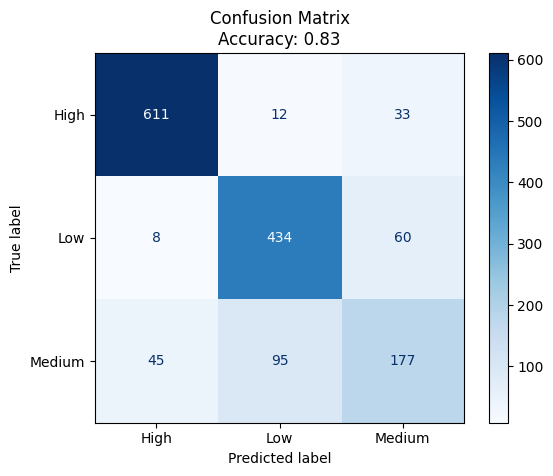

In [ ]:
# Create three decision tree models
from sklearn.tree import DecisionTreeClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Helper function to display classification results
def print_classification_summary(model_name, accuracy, report_dict, confusion_mtx, labels):
    print(f"\n{'='*30}")
    print(f"{model_name}")
    print(f"{'='*30}")
    print(f"Accuracy: {accuracy*100:.2f}%\n")
    print(f"{'Class':<12} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
    print("-" * 60)
    for label in labels:
        metrics = report_dict[label]
        print(f"{label:<12} {metrics['precision']:<10.2f} {metrics['recall']:<10.2f} {metrics['f1-score']:<10.2f} {int(metrics['support']):<10}")
    print("\nConfusion Matrix:")
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mtx, display_labels=labels)
    plt.figure(figsize=(6, 5))
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix\nAccuracy: {accuracy:.2f}")
    plt.grid(False)
    plt.show()


# ========== Model 1: Default Decision Tree ==========
model1 = DecisionTreeClassifier(random_state=42)
model1.fit(X_train, y_train)
plt.figure(figsize=(20, 10))
plot_tree(model1, feature_names=X.columns, class_names=model1.classes_, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Classifier - Model 1 (Full Depth)")
plt.show()

# ========== Model 2: Max Depth = 3 ==========
model2 = DecisionTreeClassifier(max_depth=3, random_state=42)
model2.fit(X_train, y_train)
plt.figure(figsize=(20, 10))
plot_tree(model2, feature_names=X.columns, class_names=model2.classes_, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Classifier - Model 2 (Max Depth 3)")
plt.show()

# ========== Model 3: Only 3 Features ==========
selected_features = ['popularity', 'revenue', 'profit']
X_selected = X[selected_features]
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected, y, test_size=0.2, random_state=42)
model3 = DecisionTreeClassifier( max_depth=5, random_state=42)
model3.fit(X_train_sel, y_train_sel)
plt.figure(figsize=(20, 10))
plot_tree(model3, feature_names=selected_features, class_names=model3.classes_, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Classifier - Model 3 (Selected Features)")
plt.show()

# Evaluate and neatly print classification results
for i, (name, model, X_te, y_te) in enumerate([
    ("Model 1: Default Tree", model1, X_test, y_test),
    ("Model 2: Max Depth 3", model2, X_test, y_test),
    ("Model 3: Selected Features", model3, X_test_sel, y_test_sel)
]):
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    report = classification_report(y_te, y_pred, output_dict=True)
    matrix = confusion_matrix(y_te, y_pred)
    labels = model.classes_
    print_classification_summary(name, acc, report, matrix, labels)

In [ ]:
import pandas as pd
# Load the newly uploaded dataset
df = pd.read_csv('/content/preprocessed_data.csv')

# Show basic information to decide how to create binary labels from revenue
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7398 entries, 0 to 7397
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                7398 non-null   int64  
 1   genres                7375 non-null   object 
 2   original_language     7398 non-null   object 
 3   original_title        7398 non-null   object 
 4   overview              7398 non-null   object 
 5   popularity            7398 non-null   float64
 6   production_companies  6984 non-null   object 
 7   production_countries  7241 non-null   object 
 8   runtime               7398 non-null   float64
 9   spoken_languages      7322 non-null   object 
 10  revenue               7398 non-null   float64
 11  release_year          7397 non-null   float64
 12  release_month         7397 non-null   float64
 13  release_day           7397 non-null   float64
 14  profit                7398 non-null   float64
 15  profit_margin        

(None,
      budget                                        genres original_language  \
 0    500000              Drama, Horror, Thriller, Romance                en   
 1   2300000                       Comedy, Crime, Thriller                en   
 2         0                  Thriller, Action, Drama, War                en   
 3   2000000  Adventure, Action, Thriller, Science Fiction                en   
 4  52000000                                         Drama                en   
 
   original_title                                           overview  \
 0            May  Psychological horror about a lonely young woma...   
 1        Curdled  Gabriella, a Columbian immigrant, is obsessed ...   
 2            '71  A young British soldier must find his way back...   
 3      Mad Max 2  Max Rockatansky returns as the heroic loner wh...   
 4      Apollo 13  The true story of technical troubles that scut...   
 
    popularity                               production_companies  \
 0    8.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


# Step 1: Create binary label for classification based on revenue
df['is_successful'] = (df['revenue'] >= 10000000).astype(int)

# Step 2: Drop unstructured or high-cardinality columns
df_binary = df.drop(columns=[
    'overview', 'original_title', 'production_companies',
    'production_countries', 'spoken_languages', 'revenue'
]).dropna()

# Step 3: Encode categorical columns
label_encoders = {}
for col in ['genres', 'original_language']:
    le = LabelEncoder()
    df_binary[col] = le.fit_transform(df_binary[col])
    label_encoders[col] = le

# Step 4: Separate features and target
X = df_binary.drop(columns=['is_successful'])
y = df_binary['is_successful']

# Step 5: Normalize numeric features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X.shape, y.value_counts()


((7374, 10),
 is_successful
 1    5002
 0    2372
 Name: count, dtype: int64)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Train Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# Evaluate both
results = {}

for model_name, y_pred in zip(["Logistic Regression", "Multinomial Naive Bayes"], [y_pred_log, y_pred_nb]):
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    matrix = confusion_matrix(y_test, y_pred)
    results[model_name] = {
        "accuracy": acc,
        "report": report,
        "confusion": matrix
    }

results


{'Logistic Regression': {'accuracy': 0.9511864406779661,
  'report': {'0': {'precision': 0.9090909090909091,
    'recall': 0.9523809523809523,
    'f1-score': 0.9302325581395349,
    'support': 504.0},
   '1': {'precision': 0.9746568109820486,
    'recall': 0.9505664263645726,
    'f1-score': 0.9624608967674662,
    'support': 971.0},
   'accuracy': 0.9511864406779661,
   'macro avg': {'precision': 0.9418738600364789,
    'recall': 0.9514736893727624,
    'f1-score': 0.9463467274535005,
    'support': 1475.0},
   'weighted avg': {'precision': 0.952253275691788,
    'recall': 0.9511864406779661,
    'f1-score': 0.9514486373312103,
    'support': 1475.0}},
  'confusion': array([[480,  24],
         [ 48, 923]])},
 'Multinomial Naive Bayes': {'accuracy': 0.6671186440677966,
  'report': {'0': {'precision': 0.8823529411764706,
    'recall': 0.02976190476190476,
    'f1-score': 0.05758157389635317,
    'support': 504.0},
   '1': {'precision': 0.6646090534979424,
    'recall': 0.9979402677651

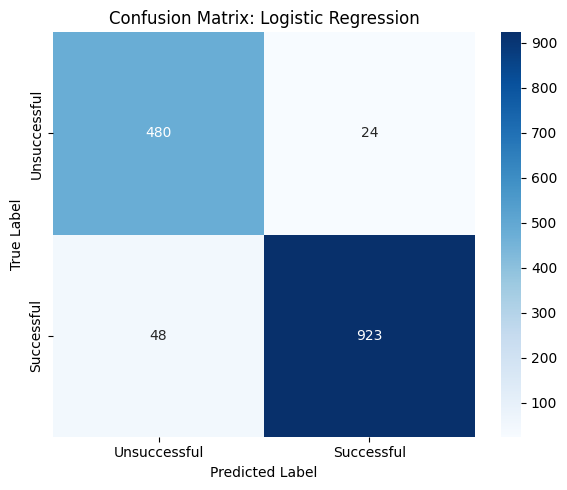

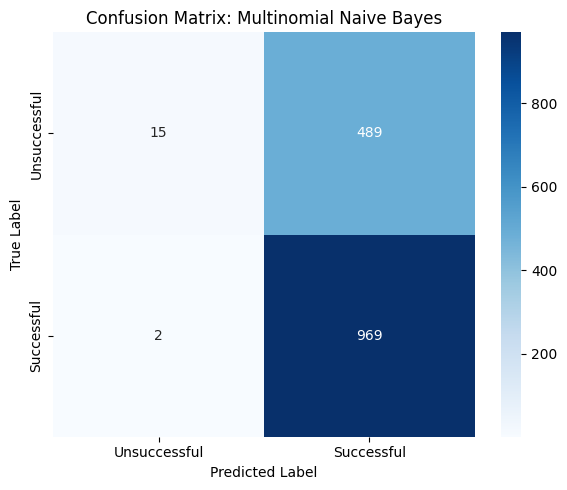

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plot both confusion matrices
def plot_conf_matrix(conf_matrix, labels, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_conf_matrix(results["Logistic Regression"]["confusion"],
                 labels=["Unsuccessful", "Successful"],
                 title="Confusion Matrix: Logistic Regression")

plot_conf_matrix(results["Multinomial Naive Bayes"]["confusion"],
                 labels=["Unsuccessful", "Successful"],
                 title="Confusion Matrix: Multinomial Naive Bayes")